# Policy Representation Tutorial

Welcome. This notebook is a guided introduction to the project from data processing to mechanistic interpretability.

The main question of this repository is simple.

**How do language models internally represent and process policy text?**

This notebook is designed for readers who are completely new to mechanistic interpretability. We will go slowly, explain the basic ideas, and connect every technical step to the scientific question.

This tutorial has two tracks.

1. A small conceptual track that runs on a tiny model and shows the core idea.
2. A repository track that shows how the real pipeline works on AGORA policy data.

Two orientation points matter from the start.

1. The project is primarily about policy representation, not about the benchmark by itself.
2. The benchmark is a structured evaluation wrapper around the main methodology.

You do not need to understand every detail on the first pass. The goal is to make the workflow legible and approachable.


## How to use this notebook

1. Read the markdown sections carefully before running the next code cell.
2. Run the notebook from top to bottom the first time.
3. Some steps are intentionally disabled by default because they are expensive. You can enable them later.
4. If a file or model is missing on your machine, the notebook will still explain what that step is supposed to do.

This notebook assumes the repository root contains `README.md`, `src/`, `scripts/`, and `configs/`.


In [ ]:
from __future__ import annotations

import json
import os
import sys
from pathlib import Path


def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        markers = [candidate / 'README.md', candidate / 'src', candidate / 'scripts', candidate / 'configs']
        if all(path.exists() for path in markers):
            return candidate
    raise RuntimeError('Could not find the repository root from the current working directory.')


REPO_ROOT = find_repo_root()
os.chdir(REPO_ROOT)
if str(REPO_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / 'src'))

print(f'Repository root: {REPO_ROOT}')
print(f'Python path now contains: {REPO_ROOT / "src"}')


In [ ]:
import platform

try:
    import torch
except ImportError:
    torch = None

print(f'Python version: {platform.python_version()}')
print(f'Platform: {platform.platform()}')
if torch is None:
    print('PyTorch is not installed in this environment.')
else:
    print(f'PyTorch version: {torch.__version__}')
    print(f'CUDA available: {torch.cuda.is_available()}')


## Repository map

Here is the practical structure of the project.

1. `src/` contains reusable code for data loading, model hooks, analysis, benchmarking, and SAE handling.
2. `scripts/` contains runnable pipeline entry points.
3. `configs/` contains experiment settings.
4. `data/processed/public_values/` stores proxy manifests and matched negatives.
5. `results/` stores discovery, transfer, and audit outputs.
6. `docs/tutorials/` contains guided notebooks and `docs/figures/` contains versioned visual assets.

In this notebook, we will move from raw policy text to internal features and then to the audit wrapper that evaluates them.


## Step 1. Locate AGORA data

The repository uses AGORA policy segments as the core corpus. The code can work with a local copy of AGORA under either of these common locations.

1. `agora/agora/`
2. `data/raw/agora/`

We will check what exists on your machine.


In [ ]:
from pathlib import Path

candidate_dirs = [
    REPO_ROOT / 'agora' / 'agora',
    REPO_ROOT / 'data' / 'raw' / 'agora',
]

for path in candidate_dirs:
    exists = path.exists()
    print(f'{path} -> {exists}')


## Step 2. Load AGORA records

The loader in `src/data/io.py` reads `documents.csv` and `segments.csv`, merges document metadata into segment records, and exposes a convenient Python list of rows.

A few details matter here.

1. The basic unit is the **segment**, not the whole document.
2. We keep AGORA string tag annotations in `tags` and `all_tags`.
3. We also keep quality flags such as `non_operative`, `not_ai_related`, `segment_annotated`, and `segment_validated`.

This lets us talk about policy text at the level where annotation and model processing are both manageable.


In [ ]:
from data.io import load_agora_records

agora_dir = None
for path in candidate_dirs:
    if path.exists():
        agora_dir = path
        break

if agora_dir is None:
    print('No AGORA directory was found. The rest of the data cells will be illustrative only.')
    records = []
else:
    records = load_agora_records(agora_dir)
    print(f'Loaded records: {len(records):,}')
    print('First record keys:')
    print(sorted(records[0].keys()))


In [ ]:
if records:
    sample = records[0]
    preview = {
        'segment_id': sample.get('segment_id'),
        'document_id': sample.get('document_id'),
        'text_preview': sample.get('text', '')[:280],
        'tags': sample.get('tags', [])[:5],
        'all_tags': sample.get('all_tags', [])[:8],
        'non_operative': sample.get('non_operative'),
        'not_ai_related': sample.get('not_ai_related'),
        'segment_annotated': sample.get('segment_annotated'),
        'segment_validated': sample.get('segment_validated'),
        'authority': sample.get('authority'),
        'jurisdiction': sample.get('jurisdiction'),
        'document_form': sample.get('document_form'),
        'year': sample.get('year'),
    }
    print(json.dumps(preview, indent=2, ensure_ascii=False))


## Step 3. Understand the core policy features

The project does not try to analyze every AGORA tag at once. That would make the paper too broad and the causal story too weak.

Instead, the v1 empirical core focuses on three related concept pairs.

1. Bias and Discrimination
2. Privacy and Rights violation
3. Transparency and Interpretability

Why these pairs?

1. They are governance relevant.
2. They are related but not identical.
3. They let us ask whether internal representations transfer across nearby policy concepts.

This is important because a model that only memorizes surface wording should struggle to generalize from one proxy to a related one.


## Step 3A. Formal setup in plain language

The project now uses a lightweight formal setup. The important word here is **lightweight**.

We do not want a notation jungle. We only define the parts that we actually measure.

1. A segment is one policy passage from AGORA.
2. A proxy task is one tagged policy concept such as `Bias` or `Privacy`.
3. A grouped split means all segments from the same document stay in the same split.
4. A dense representation is the pooled hidden state from one layer.
5. A sparse representation is the SAE feature vector built from that dense state.
6. A transfer score asks whether features found on one proxy also activate on a related proxy.
7. A robustness score asks how much performance remains after lexical masking.
8. A causal selectivity score asks whether intervening on discovered features changes target behavior more than matched random controls.

That is enough notation for an applied paper like this. The point is precision, not abstraction for its own sake.


## Step 3B. Claim ladder and what the project is not claiming

This project uses a clear evidence ladder.

1. Discovery supports a **proxy aligned feature claim**.
2. Transfer supports a **shared related feature claim**.
3. Family level interpretation is a **more cautious downstream interpretation**.

Just as important is what we do **not** claim.

1. We do not claim direct public value encoding.
2. We do not claim downstream social or policy causal impact.
3. We do not claim general learning theoretic guarantees for model training.

This distinction matters because mechanistic interpretability can easily become over interpreted if the evidence ladder is not explicit.


In [ ]:
import yaml

benchmark_cfg_path = REPO_ROOT / 'configs' / 'policy_feature_benchmark.yaml'
with benchmark_cfg_path.open('r', encoding='utf-8') as f:
    benchmark_cfg = yaml.safe_load(f)

for pair in benchmark_cfg['v1_pairs']:
    left = pair['left']['display_name']
    right = pair['right']['display_name']
    family = pair['family']
    print(f'{family}: {left} <-> {right}')


## Step 4. Build proxy manifests

The repository does not run discovery directly on raw CSV rows. First it materializes **proxy manifests**.

A proxy manifest is a set of segment rows for one concept, split by document into `train`, `dev`, and `test`.

This is useful because it freezes the data interface that downstream steps consume.

Each row in a manifest keeps:

1. the segment text
2. the proxy name
3. the family name
4. the split
5. AGORA string tags
6. quality flags
7. metadata such as authority, jurisdiction, document form, and year

The command below builds those manifests.


In [ ]:
import subprocess

RUN_HEAVY_COMMANDS = False


def run_command(command: list[str], cwd: Path = REPO_ROOT):
    print('Running command:')
    print(' '.join(command))
    result = subprocess.run(command, cwd=cwd, text=True, capture_output=True)
    print('Return code:', result.returncode)
    if result.stdout:
        print('\nSTDOUT\n')
        print(result.stdout[:6000])
    if result.stderr:
        print('\nSTDERR\n')
        print(result.stderr[:6000])
    return result


build_public_value_command = [
    sys.executable,
    'scripts/build_public_value_corpus.py',
]

print('Heavy commands are enabled:', RUN_HEAVY_COMMANDS)
if RUN_HEAVY_COMMANDS:
    run_command(build_public_value_command)
else:
    print('Set RUN_HEAVY_COMMANDS = True if you want to actually rebuild manifests.')


In [ ]:
manifest_root = REPO_ROOT / 'data' / 'processed' / 'public_values'
summary_path = manifest_root / 'summary.json'
print('Manifest root exists:', manifest_root.exists())
print('Summary exists:', summary_path.exists())

example_manifest = manifest_root / 'equality_neutrality' / 'proxies' / 'risk_factors_bias' / 'train.jsonl'
print('Example manifest:', example_manifest)
print('Exists:', example_manifest.exists())

if example_manifest.exists():
    from data.io import read_jsonl
    rows = read_jsonl(example_manifest)
    print(f'Rows in example manifest: {len(rows)}')
    print(json.dumps(rows[0], indent=2, ensure_ascii=False)[:2500])


## Step 5. Build matched negatives

Matched negatives are extremely important.

If we compare positive segments against arbitrary negatives, the model may win by using easy shortcuts such as document form, length, or jurisdiction style.

So the repository builds a matched negative set for each proxy.

The matcher tries to keep negatives similar in things like:

1. text length
2. authority
3. jurisdiction
4. document form
5. application domain
6. year

This makes the policy feature comparison more meaningful.


In [ ]:
build_negative_command = [
    sys.executable,
    'scripts/build_matched_negatives.py',
]

if RUN_HEAVY_COMMANDS:
    run_command(build_negative_command)
else:
    print('Set RUN_HEAVY_COMMANDS = True if you want to rebuild matched negatives.')


In [ ]:
negative_summary_path = manifest_root / 'negative_matching_summary.json'
print('Negative matching summary exists:', negative_summary_path.exists())

example_diag = manifest_root / 'equality_neutrality' / 'negatives' / 'risk_factors_bias' / 'diagnostics.json'
print('Example diagnostics path:', example_diag)
print('Exists:', example_diag.exists())

if example_diag.exists():
    diagnostics = json.loads(example_diag.read_text(encoding='utf-8'))
    print(json.dumps(diagnostics, indent=2, ensure_ascii=False)[:3000])


# Mechanistic Interpretability Primer

This section is intentionally gentle. If you are new to mechanistic interpretability, read this slowly.


## What is mechanistic interpretability?

Mechanistic interpretability asks **how a model computes**, not only **what accuracy it gets**.

A useful mental model is this.

1. A model reads tokens.
2. Every layer transforms the current internal state.
3. Information is written into and read from internal vectors.
4. We study those internal vectors to understand what the model is representing.

In this project, we are asking whether policy concepts such as bias, privacy, or transparency show up as recoverable internal structure.


## What is an activation?

An activation is simply a numerical vector produced inside the network.

You can think of it as the current internal state of the model at some point in the computation.


## What is the residual stream?

The residual stream is the running workspace that passes from one transformer block to the next.

A simple way to think about it is this.

1. layer 0 creates an initial representation of the text
2. layer 1 reads that representation and writes an updated version
3. layer 2 does the same
4. later layers keep refining the same running workspace

So when we inspect the residual stream, we are looking at the model's shared internal memory for the sequence.

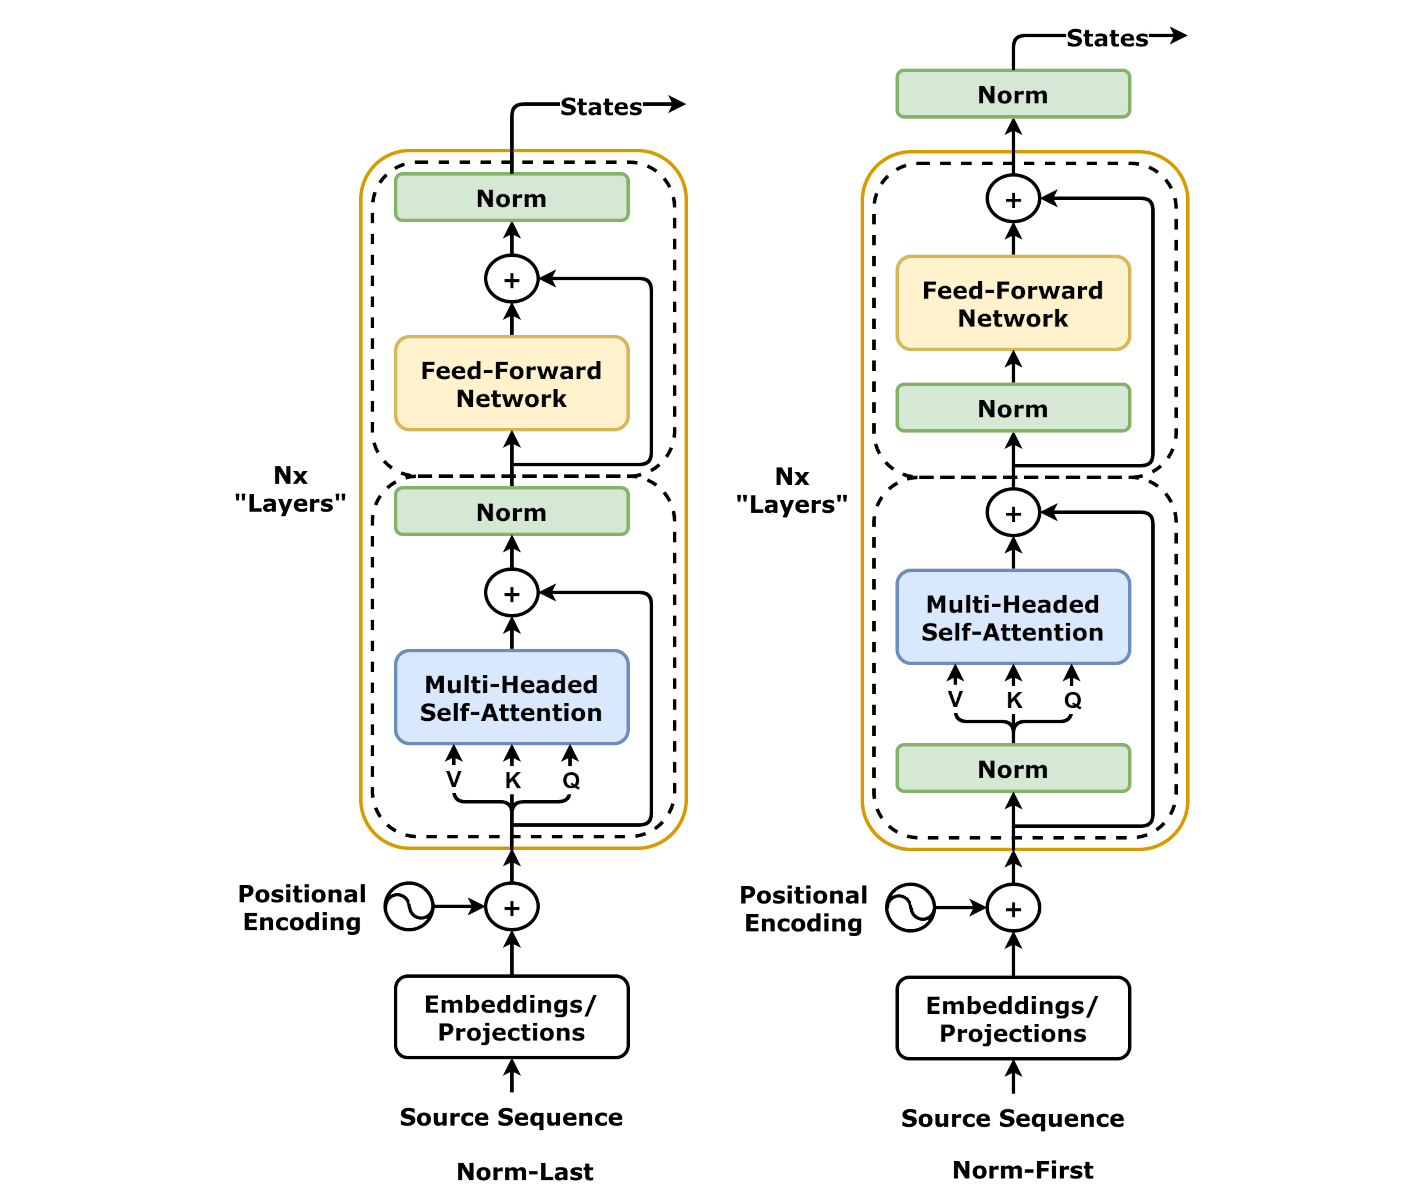

Source: [Wikimedia Commons, Transformer encoder block](https://commons.wikimedia.org/wiki/File:Transformer_encoder,_with_norm-first_and_norm-last.png)

The internet sourced figure above is a compact Transformer block schematic. For our purposes, the key idea is the residual path. Attention and MLP components both read from the shared workspace and write updates back into it. This is why `resid_post` is a useful site for policy representation analysis: it is where the layer's contribution has already been merged into the running internal state.


## What is a layer site?

A site is the exact place in the model where we choose to look.

In this repository, the most common site is `resid_post`, which means the residual stream after a layer has finished writing to it.

Other common sites are attention output and MLP output.


## What is pooling?

A policy segment can be many tokens long. But downstream analysis often needs one vector per segment.

Pooling means turning a sequence of token vectors into one segment vector.

This repository uses:

1. `mean` pooling for the main path
2. `max` pooling for robustness checks

Mean pooling asks, "what is the average internal representation across the segment?"

Max pooling asks, "which dimensions were strongly active anywhere in the segment?"


## What is an SAE feature?

A sparse autoencoder, often abbreviated SAE, tries to rewrite a dense activation vector using a sparse set of learned features.

The useful intuition is this.

1. the dense residual vector is hard to interpret directly
2. an SAE maps it into a sparse feature space
3. some sparse features may align with human recognizable concepts more clearly than raw dense dimensions

We never assume this automatically proves meaning. We still need careful validation.

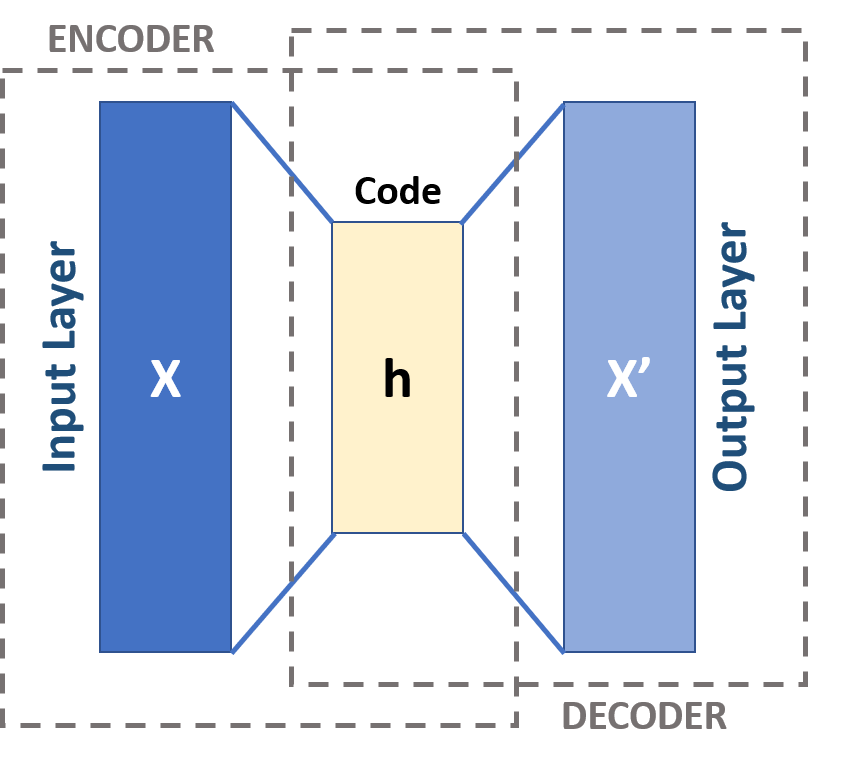

Source: [Wikimedia Commons, Autoencoder schema](https://commons.wikimedia.org/wiki/File:Autoencoder_schema.png)

The internet sourced figure above shows the basic encoder code decoder pattern. In our project, the input is not an image. It is a model activation such as a pooled residual representation. The sparse code is what we inspect when we talk about discovered policy features.


## What is feature discovery?

Feature discovery means comparing positive and negative examples and asking:

**Which internal dimensions are reliably more active for the positive policy concept?**

For example:

1. positive examples might be segments tagged with `Risk factors: Bias`
2. matched negatives are similar segments without that proxy
3. a discovered feature is one that consistently differentiates the two groups


## What is transfer?

Transfer asks whether a feature discovered for one proxy also helps on a related proxy.

For example:

1. discover a feature bank on `Bias`
2. test it on `Discrimination`
3. compare that to out of family transfer targets

If transfer works within related concept pairs better than across unrelated pairs, that is evidence for shared internal structure.



Source: [Wikimedia Commons, Transfer learning](https://commons.wikimedia.org/wiki/File:Transfer_learning.svg)

The internet sourced figure above is a generic transfer learning picture rather than a policy specific one. It is still useful here because the core idea is the same: structure learned on one task is tested for reuse on a related task. Our paper adapts that intuition to policy proxies by asking whether a feature bank discovered on one policy concept transfers better to its paired concept than to unrelated controls.


## What is intervention?

Intervention means changing an internal feature and seeing whether model behavior changes.

Examples include:

1. ablation, which suppresses a feature
2. clamping, which forces a feature toward a value
3. patching, which swaps internal activations between inputs

Intervention is how we move from correlation toward causal evidence.


## Step 6. A tiny hands on Mech Interp demo

Before we touch the full AGORA pipeline, we will do a tiny toy example.

Important caution.

1. This is not the real experiment.
2. This uses a tiny language model on a tiny hand written dataset.
3. The goal is only to show the mechanics of ?capture an internal representation, pool it, and train a simple classifier on top.?

If this section makes sense, the full pipeline will feel much less mysterious.


In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
import numpy as np
import torch

from model.hooks import capture_layer_site_sequence, pool_sequence_activations


toy_texts = [
    'The agency should assess whether the system causes biased outcomes across demographic groups.',
    'Developers must evaluate discrimination risks before deploying this AI service.',
    'The policy requires mitigation plans for unequal treatment caused by automated scoring.',
    'Auditors should check whether model outputs disadvantage protected groups.',
    'The provider must publish documentation that makes the model easier to interpret.',
    'Agencies should disclose how the system works so the public can understand it.',
    'The rule emphasizes transparency reports and interpretable design requirements.',
    'This policy asks developers to explain system behavior in accessible terms.',
]

toy_labels = np.array([1, 1, 1, 1, 0, 0, 0, 0], dtype=np.int64)

model_id = 'sshleifer/tiny-gpt2'
tokenizer = AutoTokenizer.from_pretrained(model_id)
if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token
model = AutoModelForCausalLM.from_pretrained(model_id)
model.eval()

x_train, x_test, y_train, y_test = train_test_split(
    toy_texts,
    toy_labels,
    test_size=0.25,
    random_state=0,
    stratify=toy_labels,
)


def encode_toy_texts(texts: list[str], layer: int = 1, site: str = 'resid_post', pooling: str = 'mean') -> np.ndarray:
    encoded_vectors = []
    for text in texts:
        enc = tokenizer([text], return_tensors='pt', padding=True, truncation=True, max_length=128)
        with torch.no_grad():
            sequence_states = capture_layer_site_sequence(model, layer=layer, site=site, inputs=enc)
            pooled = pool_sequence_activations(sequence_states, attention_mask=enc['attention_mask'], pooling=pooling)
        encoded_vectors.append(pooled.squeeze(0).cpu().numpy())
    return np.stack(encoded_vectors, axis=0)


train_features = encode_toy_texts(x_train)
test_features = encode_toy_texts(x_test)
clf = LogisticRegression(max_iter=1000)
clf.fit(train_features, y_train)
probs = clf.predict_proba(test_features)[:, 1]
auc = roc_auc_score(y_test, probs)

print('Toy train feature shape:', train_features.shape)
print('Toy test feature shape:', test_features.shape)
print('Toy AUC:', round(float(auc), 4))


## What did the toy demo just do?

It did three small but important things.

1. It passed text through a language model.
2. It captured the residual stream at one layer.
3. It turned that internal vector into features for a simple classifier.

That is already enough to illustrate a central idea of mechanistic interpretability work.

**We can look inside the model, extract internal representations, and ask whether they contain task relevant information.**

What the toy demo did **not** prove.

1. It did not prove concept understanding.
2. It did not prove causal use.
3. It did not prove transfer across related proxies.
4. It did not use matched negatives.
5. It did not use SAEs.

So treat it as a comfort building example, not as a scientific result.


## Step 7. Real proxy discovery

Now we return to the real pipeline.

Proxy discovery asks:

**Which dense or sparse internal features reliably separate one policy concept from matched negatives?**

In the repository, the discovery runner:

1. loads one proxy manifest
2. loads its matched negatives
3. extracts internal representations from the model
4. computes difference statistics on the train split
5. freezes a feature bank
6. evaluates that bank on the held out test split

The main discovery configuration lives in `configs/policy_mech_interp.yaml`.


In [ ]:
policy_cfg_path = REPO_ROOT / 'configs' / 'policy_mech_interp.yaml'
print(policy_cfg_path.read_text(encoding='utf-8'))


In [ ]:
discovery_command = [
    sys.executable,
    'scripts/run_proxy_discovery.py',
    '--family', 'equality_neutrality',
    '--proxy_slug', 'risk_factors_bias',
    '--layer', '24',
    '--site', 'resid_post',
]

print('Example discovery command:')
print(' '.join(discovery_command))

if RUN_HEAVY_COMMANDS:
    run_command(discovery_command)


In [ ]:
feature_bank_candidates = sorted((REPO_ROOT / 'results').rglob('feature_bank.json'))
print(f'Found feature banks: {len(feature_bank_candidates)}')
if feature_bank_candidates:
    candidate = feature_bank_candidates[0]
    print('Example feature bank path:')
    print(candidate)
    payload = json.loads(candidate.read_text(encoding='utf-8'))
    preview = {
        'family_name': payload.get('family_name'),
        'proxy_slug': payload.get('proxy_slug'),
        'layer': payload.get('layer'),
        'site': payload.get('site'),
        'pooling': payload.get('pooling'),
        'n_features': len(payload.get('feature_ids', [])),
        'first_feature_ids': payload.get('feature_ids', [])[:10],
    }
    print(json.dumps(preview, indent=2))


## Step 8. Transfer across related policy features

Transfer is one of the most important steps in the project.

A single proxy can often be solved with shallow cues. Transfer makes the test harder.

For example:

1. discover a feature bank for `Bias`
2. apply that bank to `Discrimination`
3. compare the result to out of family transfer targets

This is how we test whether internal structure generalizes beyond one annotation string.


## Step 8A. Evidence hierarchy and statistical testing

Before we run the heavier parts of the pipeline, it helps to know how the project weighs evidence.

The project separates **primary comparisons** from **exploratory comparisons**.

Primary comparisons

1. within pair transfer
2. keyword masking deltas
3. intervention selectivity against matched random controls

Exploratory comparisons

1. layerwise activation profiles
2. family overlap visualizations

This separation is useful for two reasons.

1. It keeps the narrative tied to the strongest evidence.
2. It prevents every interesting visualization from being treated like a locked headline result.

The statistical defaults follow the same philosophy.

1. discovery uses document clustered permutation tests with BH FDR correction
2. held out method comparisons use paired bootstrap confidence intervals on the same evaluation rows
3. layer selection and feature selection are done on train only
4. the test split is locked for final reporting

That combination makes the pipeline more defensible without turning it into a theory heavy document.


In [ ]:
transfer_command = [
    sys.executable,
    'scripts/run_proxy_transfer.py',
    '--source_family', 'equality_neutrality',
    '--source_proxy_slug', 'risk_factors_bias',
    '--target_family', 'equality_neutrality',
    '--target_proxy_slug', 'harms_discrimination',
]

print('Example transfer command:')
print(' '.join(transfer_command))

if RUN_HEAVY_COMMANDS:
    run_command(transfer_command)


In [ ]:
transfer_candidates = sorted((REPO_ROOT / 'results').rglob('risk_factors_bias__to__harms_discrimination.json'))
print(f'Found matching transfer result files: {len(transfer_candidates)}')
if transfer_candidates:
    candidate = transfer_candidates[0]
    print('Example transfer file:')
    print(candidate)
    payload = json.loads(candidate.read_text(encoding='utf-8'))
    preview = {
        'source_proxy_name': payload.get('source_proxy_name'),
        'target_proxy_name': payload.get('target_proxy_name'),
        'family_relation': payload.get('family_relation'),
        'feature_transfer_auc': payload.get('feature_transfer_auc'),
        'feature_transfer_auc_masked': payload.get('feature_transfer_auc_masked'),
        'lexical_baseline_auc': payload.get('lexical_baseline_auc'),
        'lexical_baseline_auc_masked': payload.get('lexical_baseline_auc_masked'),
    }
    print(json.dumps(preview, indent=2))


## Step 9. Evaluation protocol for the mechanistic pipeline

At this stage, the project packages the mechanistic pipeline into a standardized evaluation protocol.

The scientific core is still the same:

1. discovery on matched positives and negatives
2. transfer across related policy features
3. masking based robustness checks
4. intervention based causal qualification

The benchmark is useful because it makes these stages comparable across methods, but the scientific logic still comes from the mechanistic pipeline itself.


In [ ]:
preflight_command = [
    sys.executable,
    'scripts/run_policy_feature_benchmark.py',
    '--preflight_only',
]

print('Example benchmark preflight command:')
print(' '.join(preflight_command))

if RUN_HEAVY_COMMANDS:
    run_command(preflight_command)


In [ ]:
preflight_path = REPO_ROOT / 'results' / 'policy_feature_benchmark' / 'summary' / 'preflight_report.json'
print('Preflight path exists:', preflight_path.exists())
if preflight_path.exists():
    preflight = json.loads(preflight_path.read_text(encoding='utf-8'))
    print(json.dumps(preflight, indent=2, ensure_ascii=False)[:4000])


In [ ]:
full_benchmark_command = [
    sys.executable,
    'scripts/run_policy_feature_benchmark.py',
    '--config', 'configs/policy_feature_benchmark.yaml',
    '--output_root', 'results/policy_feature_benchmark',
]
aggregate_benchmark_command = [
    sys.executable,
    'scripts/aggregate_policy_feature_benchmark.py',
    '--config', 'configs/policy_feature_benchmark.yaml',
    '--output_root', 'results/policy_feature_benchmark',
]
print('Example full benchmark command:')
print(' '.join(full_benchmark_command))
print('
Example benchmark aggregation command:')
print(' '.join(aggregate_benchmark_command))


## Step 10. From mechanistic evidence to policy analysis support

The project now extends the mechanistic pipeline into a policy analysis assistant layer.

It helps with three practical tasks.

1. highlighting policy relevant segments
2. retrieving segments with similar policy logic
3. triaging which parts of a document deserve closer review

It is important to separate the scientific core from the presentation layer.

Scientific core:

1. discovery
2. transfer
3. masking
4. intervention

Assistant facing presentation layer:

1. concern score
2. related support score
3. reliability score
4. priority score
5. grounded natural language rendering


## Step 10A. Assistant facing output objects

The assistant produces structured objects rather than only a single label.

1. `segment_card`
   Contains the segment text, the family or proxy anchor, numeric evidence fields, retrieval examples, and a grounded explanation.
2. `document_brief`
   Summarizes dominant families, top segments by family, family scores, and review order.
3. retrieval examples
   Show similar segments from the corpus that share related policy logic.
4. grounded natural language note
   Renders the numeric evidence into an analyst friendly sentence without replacing the underlying scores.


In [ ]:
assistant_command = [
    sys.executable,
    'scripts/run_policy_analysis_experiments.py',
    '--config', 'configs/policy_analysis_assistant.yaml',
    '--output_root', 'results/policy_analysis_assistant',
]
single_document_command = [
    sys.executable,
    'scripts/run_policy_document_analysis.py',
    '--input_path', 'path/to/document.txt',
    '--config', 'configs/policy_analysis_assistant_sae.yaml',
    '--output_path', 'results/policy_document_analysis.json',
]
print('Example assistant suite command:')
print(' '.join(assistant_command))
print('
Example single document analysis command:')
print(' '.join(single_document_command))


## Step 11. Lambda full run commands

Once local tests and smoke runs are complete, the full expensive stages can move to Lambda.

The repository includes a one line runbook in `docs/lambda_runbook.md`. The full sequence is:

1. pull `main`
2. create the environment
3. authenticate to Hugging Face
4. build proxy manifests
5. build matched negatives
6. run benchmark preflight
7. run benchmark cheap
8. run benchmark dense
9. run benchmark sparse
10. aggregate benchmark outputs
11. run assistant cheap
12. run assistant dense
13. run assistant sparse
14. optionally run single document analysis


In [ ]:
lambda_commands = [
    'git checkout main && git pull --ff-only',
    'python3 -m venv .venv && source .venv/bin/activate && python -m pip install --upgrade pip && pip install -r requirements.txt',
    'export HF_TOKEN="YOUR_HF_TOKEN" && python -c "from huggingface_hub import login; import os; login(token=os.environ['HF_TOKEN'])"',
    'python scripts/build_public_value_corpus.py',
    'python scripts/build_matched_negatives.py',
    'python scripts/run_policy_feature_benchmark.py --preflight_only --config configs/policy_feature_benchmark.yaml --output_root results/policy_feature_benchmark_lambda',
    'python scripts/run_policy_feature_benchmark.py --config configs/policy_feature_benchmark_cheap.yaml --output_root results/policy_feature_benchmark_lambda',
    'python scripts/run_policy_feature_benchmark.py --config configs/policy_feature_benchmark_dense.yaml --output_root results/policy_feature_benchmark_lambda',
    'python scripts/run_policy_feature_benchmark.py --config configs/policy_feature_benchmark_sae.yaml --output_root results/policy_feature_benchmark_lambda',
    'python scripts/aggregate_policy_feature_benchmark.py --config configs/policy_feature_benchmark.yaml --output_root results/policy_feature_benchmark_lambda',
    'python scripts/run_policy_analysis_experiments.py --config configs/policy_analysis_assistant_cheap.yaml --output_root results/policy_analysis_assistant_lambda',
    'python scripts/run_policy_analysis_experiments.py --config configs/policy_analysis_assistant_dense.yaml --output_root results/policy_analysis_assistant_lambda',
    'python scripts/run_policy_analysis_experiments.py --config configs/policy_analysis_assistant_sae.yaml --output_root results/policy_analysis_assistant_lambda',
    'python scripts/run_policy_document_analysis.py --input_path path/to/document.txt --config configs/policy_analysis_assistant_sae.yaml --output_path results/policy_document_analysis_lambda.json --document_id lambda_doc_1 --title "Lambda Document" --source_type lambda_text',
]
for command in lambda_commands:
    print(command)


## Step 12. Where to read outputs

After you run the pipeline, these directories matter the most.

1. `data/processed/public_values/`
   Contains proxy manifests and matched negatives.
2. `results/policy_feature_benchmark/`
   Contains benchmark summaries and mechanistic comparison outputs.
3. `results/policy_analysis_assistant/`
   Contains assistant leaderboards, retrieval summaries, triage summaries, and trust bundle outputs.
4. `results/policy_document_analysis.json`
   Contains a single document analysis export for the sparse assistant.
5. `docs/lambda_runbook.md`
   Contains the full Lambda command sequence for the expensive runs.


In [ ]:
important_paths = [
    REPO_ROOT / 'data' / 'processed' / 'public_values',
    REPO_ROOT / 'results' / 'policy_feature_benchmark',
    REPO_ROOT / 'results' / 'policy_analysis_assistant',
    REPO_ROOT / 'results' / 'policy_document_analysis.json',
    REPO_ROOT / 'docs' / 'lambda_runbook.md',
]
for path in important_paths:
    print(path, 'exists=', path.exists())
